# Saudi women in work: analysis notebook

**Question.** The unemployment rate among Saudi women fell from 12.8% in the second quarter of 2024 to 9.6% in the second quarter of 2026. Did that happen because more Saudi women are working, or because fewer are looking for work?

**Approach.** Read three rates from the same survey side by side: the participation rate, the employment-to-population ratio and the unemployment rate. They are tied together by one identity, so a change in one can be traced to the other two.

**Data.** `data/processed/saudi_labour_tidy.csv`, built by `scripts/build_data.py` from the quarterly Labour Force Survey releases of the General Authority for Statistics (GASTAT). Every reading and its source link is in `data/raw/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.1f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

raw = pd.read_csv("../data/raw/saudi_labour_readings_by_source.csv")
tidy = pd.read_csv("../data/processed/saudi_labour_tidy.csv")
windows = pd.read_csv("../data/processed/window_comparisons.csv")
tidy.head()

,quarter,quarter_start,year,quarter_number,nationality,sex,indicator,value_pct,n_documents,n_publishers,verification,survey_design
0,2021-Q1,2021-01-01,2021,1,Non-Saudi,Female,participation_rate,38.5,1,1,single-document,earlier questionnaire
1,2021-Q1,2021-01-01,2021,1,Saudi,Female,participation_rate,31.9,1,1,single-document,earlier questionnaire
2,2021-Q1,2021-01-01,2021,1,Saudi,Male,participation_rate,64.8,1,1,single-document,earlier questionnaire
3,2021-Q1,2021-01-01,2021,1,Saudi,Total,participation_rate,48.3,1,1,single-document,earlier questionnaire
4,2021-Q2,2021-04-01,2021,2,Non-Saudi,Female,participation_rate,38.5,1,1,single-document,earlier questionnaire


## 1. Load and check the data

In [2]:
key = ["quarter", "nationality", "sex", "indicator"]
print("Raw readings:", len(raw), "from", raw.source.nunique(), "documents")
print("Tidy rows:", len(tidy), "| Quarters:", tidy.quarter.min(), "to", tidy.quarter.max())
print("Missing values:", int(tidy.isna().sum().sum()))
print("Duplicate quarter-group-indicator rows:", int(tidy.duplicated(key).sum()))
print("Values outside 0 to 100:", int(((tidy.value_pct < 0) | (tidy.value_pct > 100)).sum()))
spread = raw.groupby(key).value_pct.agg(["min", "max"])
print("Figures where two sources disagree:", int((spread["min"] != spread["max"]).sum()))

Raw readings: 337 from 15 documents
Tidy rows: 160 | Quarters: 2021-Q1 to 2026-Q2
Missing values: 0
Duplicate quarter-group-indicator rows: 0
Values outside 0 to 100: 0
Figures where two sources disagree: 0


Coverage is uneven, so it is checked before any comparison is made. Participation runs for 22 quarters. The unemployment rate and the employment ratio are available for 12 quarters: the second quarter of 2023, then every quarter from the fourth quarter of 2023. The third quarter of 2023 is missing for those two and is left missing.

In [3]:
coverage = (tidy.groupby(["nationality", "sex", "indicator"]).quarter
                .agg(quarters="count", first="min", last="max").reset_index())
coverage

,nationality,sex,indicator,quarters,first,last
0,Non-Saudi,Female,participation_rate,22,2021-Q1,2026-Q2
1,Saudi,Female,employment_to_population,12,2023-Q2,2026-Q2
2,Saudi,Female,participation_rate,22,2021-Q1,2026-Q2
3,Saudi,Female,unemployment_rate,12,2023-Q2,2026-Q2
4,Saudi,Male,employment_to_population,12,2023-Q2,2026-Q2
5,Saudi,Male,participation_rate,22,2021-Q1,2026-Q2
6,Saudi,Male,unemployment_rate,12,2023-Q2,2026-Q2
7,Saudi,Total,employment_to_population,12,2023-Q2,2026-Q2
8,Saudi,Total,participation_rate,22,2021-Q1,2026-Q2
9,Saudi,Total,unemployment_rate,12,2023-Q2,2026-Q2


Each figure is labelled by how well it is confirmed. `two-publishers` means GASTAT and at least one other publisher report the same number. `two-gastat-releases` means two separate GASTAT releases repeat it. `single-document` means it was read from one document only.

In [4]:
pd.crosstab(tidy.indicator, tidy.verification)

verification,single-document,two-gastat-releases,two-publishers
indicator,,,
employment_to_population,12,17,7
participation_rate,46,0,42
unemployment_rate,8,15,13


**Identity check.** The three rates are linked: employment ratio = participation rate x (1 - unemployment rate). Published figures are rounded to one decimal, so the two sides should agree to within about 0.1 of a point. A larger gap would mean a number was misread.

In [5]:
saudi = tidy[tidy.nationality == "Saudi"].pivot_table(index=["quarter", "sex"], columns="indicator", values="value_pct").dropna()
saudi["implied_employment_ratio"] = saudi.participation_rate * (1 - saudi.unemployment_rate / 100)
saudi["gap"] = (saudi.implied_employment_ratio - saudi.employment_to_population).abs()
print("Rows checked:", len(saudi))
print("Largest gap: %.2f points" % saudi.gap.max())
assert saudi.gap.max() <= 0.15

Rows checked: 36
Largest gap: 0.08 points


## 2. Saudi women: three rates side by side

In [6]:
women = (tidy[(tidy.nationality == "Saudi") & (tidy.sex == "Female")]
         .pivot(index="quarter", columns="indicator", values="value_pct")
         .loc["2023-Q4":, ["participation_rate", "employment_to_population", "unemployment_rate"]])
women["unemployed_share"] = (women.participation_rate - women.employment_to_population).round(1)
women

indicator,participation_rate,employment_to_population,unemployment_rate,unemployed_share
quarter,,,,
2023-Q4,35.0,30.1,13.9,4.9
2024-Q1,35.8,30.7,14.2,5.1
2024-Q2,35.4,30.8,12.8,4.6
2024-Q3,36.2,31.3,13.6,4.9
2024-Q4,36.0,31.8,11.9,4.2
2025-Q1,36.3,32.5,10.5,3.8
2025-Q2,34.5,30.6,11.3,3.9
2025-Q3,33.7,29.7,12.1,4.0
2025-Q4,34.5,31.0,10.3,3.5


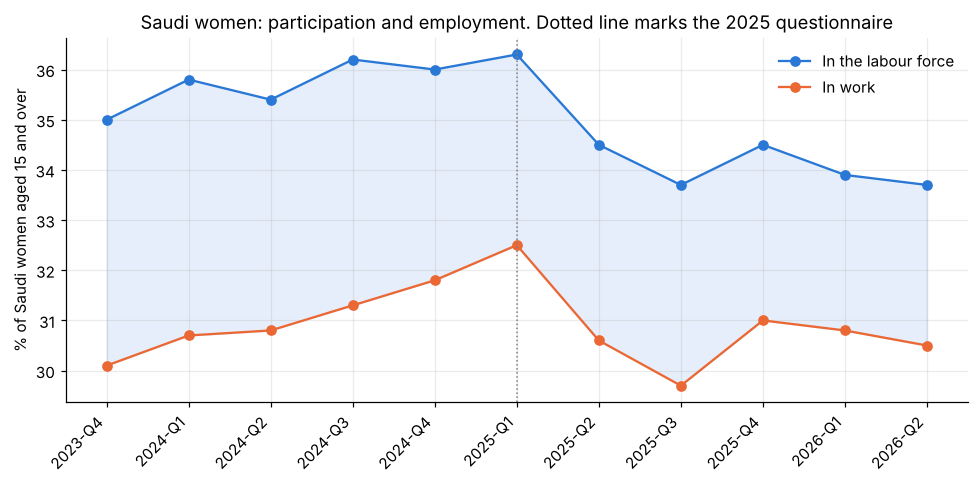

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(women))
ax.fill_between(x, women.employment_to_population, women.participation_rate, alpha=0.12, color="#2a78d6")
ax.plot(x, women.participation_rate, marker="o", color="#2a78d6", label="In the labour force")
ax.plot(x, women.employment_to_population, marker="o", color="#eb6834", label="In work")
ax.axvline(list(women.index).index("2025-Q1"), color="grey", linestyle=":", linewidth=1)
ax.set_xticks(list(x)); ax.set_xticklabels(women.index, rotation=45, ha="right")
ax.set_ylabel("% of Saudi women aged 15 and over")
ax.set_title("Saudi women: participation and employment. Dotted line marks the 2025 questionnaire")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The gap between the two lines is the share of all Saudi women who are unemployed and looking for work. It narrowed from 4.6% of women in Q2 2024 to 3.2% in Q2 2026. The lower line, the share in work, ended about where it started.

## 3. Where did the fall in unemployment come from?

The unemployment rate is `1 - employment ratio / participation rate`. To separate the two effects, hold participation at its starting level and ask what the unemployment rate would be with the employment ratio actually observed at the end. The headline window compares the same quarter two years apart, which avoids seasonal effects.

In [8]:
def compare(sex, start, end):
    s = tidy[(tidy.nationality == "Saudi") & (tidy.sex == sex)].pivot(index="quarter", columns="indicator", values="value_pct")
    a, b = s.loc[start], s.loc[end]
    return pd.Series({
        "participation_change_pts": round(b.participation_rate - a.participation_rate, 1),
        "employment_ratio_change_pts": round(b.employment_to_population - a.employment_to_population, 1),
        "unemployment_rate_start": a.unemployment_rate,
        "unemployment_rate_end": b.unemployment_rate,
        "unemployment_rate_change_pts": round(b.unemployment_rate - a.unemployment_rate, 1),
        "unemployment_rate_end_if_participation_unchanged": round(100 * (1 - b.employment_to_population / a.participation_rate), 1),
    })

headline = pd.DataFrame({"Saudi women": compare("Female", "2024-Q2", "2026-Q2"),
                         "Saudi men": compare("Male", "2024-Q2", "2026-Q2")})
headline

,Saudi women,Saudi men
participation_change_pts,-1.7,-2.4
employment_ratio_change_pts,-0.3,-2.8
unemployment_rate_start,12.8,4.0
unemployment_rate_end,9.6,4.8
unemployment_rate_change_pts,-3.2,0.8
unemployment_rate_end_if_participation_unchanged,13.8,8.3


For Saudi women the unemployment rate fell 3.2 points while the share in work slipped 0.3 points. Had participation stayed at 35.4%, the same level of employment would give an unemployment rate of 13.8%, higher than the 12.8% at the start. All of the fall is accounted for by lower participation.

For Saudi men the direction is different: the share in work fell 2.8 points and the unemployment rate rose 0.8 points. Lower participation held the male unemployment rate down; at unchanged participation it would be 8.3%.

## 4. Does the result depend on the window?

GASTAT redesigned the survey questionnaire and drew a new sample in the first quarter of 2025. The two-year window crosses that change, so the comparison is repeated on two windows that sit entirely on the new questionnaire.

In [9]:
cols = ["window", "sex", "start_quarter", "end_quarter", "participation_change_pts",
        "employment_ratio_change_pts", "unemployment_rate_change_pts",
        "unemployment_rate_end_if_participation_unchanged"]
windows[cols]

,window,sex,start_quarter,end_quarter,participation_change_pts,employment_ratio_change_pts,unemployment_rate_change_pts,unemployment_rate_end_if_participation_unchanged
0,two years,Female,2024-Q2,2026-Q2,-1.7,-0.3,-3.2,13.8
1,two years,Male,2024-Q2,2026-Q2,-2.4,-2.8,0.8,8.3
2,one year,Female,2025-Q2,2026-Q2,-0.8,-0.1,-1.7,11.6
3,one year,Male,2025-Q2,2026-Q2,-0.1,-0.5,0.5,5.0
4,since 2025 redesign,Female,2025-Q1,2026-Q2,-2.6,-2.0,-0.9,16.0
5,since 2025 redesign,Male,2025-Q1,2026-Q2,-2.5,-3.0,0.8,8.4


On every window the share of Saudi women in work is flat or lower and participation is lower. The size differs: over one year the employment ratio is unchanged within rounding (down 0.1), and from the first redesigned quarter it is down 2.0 points. The direction of the finding does not depend on the window. Its size does, and the one-year figure is the most cautious reading.

**A sign that the redesign matters.** Participation of non-Saudi women jumped from about 28% to about 36% between the last quarter of 2024 and the first quarter of 2025. A move of that size in one quarter points to the survey change, which is why comparisons across that quarter are treated with care here.

In [10]:
ns = tidy[(tidy.nationality == "Non-Saudi") & (tidy.quarter >= "2024-Q1")]
ns.groupby("survey_design", sort=False).value_pct.agg(["count", "mean", "min", "max"]).round(1)

,count,mean,min,max
survey_design,,,,
earlier questionnaire,4,28.2,27.9,28.9
2025 questionnaire,6,35.8,34.7,37.1


## 5. Participation since 2021 and the 2030 ambition

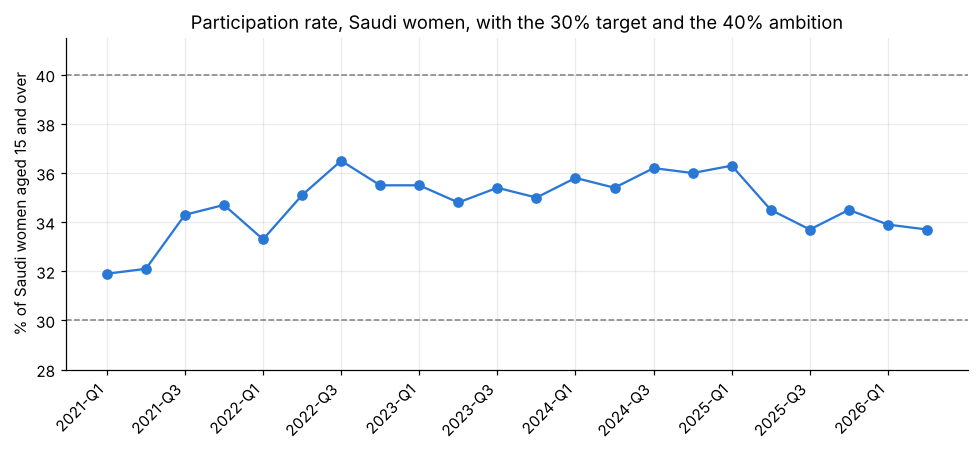

Latest: 33.7 | Short of 40%: 6.3 points
Highest quarter: 2022-Q3 36.5 (single-document)
Highest quarter confirmed in two sources: 2025-Q1 36.3


In [11]:
lf = tidy[(tidy.nationality == "Saudi") & (tidy.sex == "Female") & (tidy.indicator == "participation_rate")].set_index("quarter")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(len(lf)), lf.value_pct, marker="o", color="#2a78d6")
ax.axhline(30, color="grey", linestyle="--", linewidth=1); ax.axhline(40, color="grey", linestyle="--", linewidth=1)
ax.set_xticks(range(0, len(lf), 2)); ax.set_xticklabels(lf.index[::2], rotation=45, ha="right")
ax.set_ylim(28, 41.5); ax.set_ylabel("% of Saudi women aged 15 and over")
ax.set_title("Participation rate, Saudi women, with the 30% target and the 40% ambition")
plt.tight_layout(); plt.show()

latest = lf.value_pct["2026-Q2"]
print("Latest:", latest, "| Short of 40%%: %.1f points" % (40 - latest))
print("Highest quarter:", lf.value_pct.idxmax(), lf.value_pct.max(), "(" + lf.verification[lf.value_pct.idxmax()] + ")")
print("Highest quarter confirmed in two sources:", lf[lf.verification != "single-document"].value_pct.idxmax(), lf[lf.verification != "single-document"].value_pct.max())

## 6. Check against the build script

The figures used in the write-up are recomputed here and compared with `window_comparisons.csv`, so the notebook and the build script cannot drift apart.

In [12]:
w = windows.set_index(["window", "sex"])
for label, start, end in [("two years", "2024-Q2", "2026-Q2"), ("one year", "2025-Q2", "2026-Q2"), ("since 2025 redesign", "2025-Q1", "2026-Q2")]:
    for sex in ("Female", "Male"):
        mine = compare(sex, start, end)
        for col in ["participation_change_pts", "employment_ratio_change_pts", "unemployment_rate_change_pts",
                    "unemployment_rate_end_if_participation_unchanged"]:
            assert abs(mine[col] - w.loc[(label, sex), col]) < 1e-9, (label, sex, col)

f = w.loc[("two years", "Female")]
assert (f.unemployment_rate_start, f.unemployment_rate_end) == (12.8, 9.6)
assert (f.employment_ratio_start, f.employment_ratio_end) == (30.8, 30.5)
assert (f.participation_start, f.participation_end) == (35.4, 33.7)
assert f.unemployment_rate_end_if_participation_unchanged == 13.8
assert round(40 - latest, 1) == 6.3
print("All headline figures match the build script output.")

All headline figures match the build script output.


## Findings

1. Unemployment among Saudi women fell from 12.8% to 9.6% in two years. The share of Saudi women in work went from 30.8% to 30.5%.
2. Participation fell from 35.4% to 33.7%. At unchanged participation the unemployment rate would be 13.8%.
3. For Saudi men the share in work fell 2.8 points over the same two years, and their unemployment rate rose from 4.0% to 4.8%.
4. Women's participation is 6.3 points short of the 40% ambition for 2030, and further from it than in any second quarter since 2022.

**Limits.** Rates are published to one decimal and without margins of error in the releases used, so moves of a few tenths of a point should be read as no change. The 2025 questionnaire change affects comparisons across the first quarter of 2025. This analysis describes what the rates did. It does not show why participation fell.